# Qwen3-VL-8B - simple plot - bigger fonthes:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

# 1. Uninstall torchaudio
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# 2. Install PyTorch with CUDA 12.4
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# 3. Install latest transformers and accelerate (allowing pip to pull compatible tokenizers naturally)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Installation complete — restart the kernel now")



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.16.0.dev0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.23.1 which is incompatible.


Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Fri Aug 21 11:36:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   37C    P0            133W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [3]:
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
from e1_utils.sampling import build_paired_sample

In [4]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [5]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")


Using device: cuda


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✅ Loaded successfully


In [ ]:
import torch

# `mem_get_info` reports DEVICE-WIDE free memory, across all processes -- this is the number to
# check before starting another notebook on the same GPU. `memory_reserved` only sees the current
# process, so it cannot tell you whether a second model will fit; a cell that printed it under the
# label "VRAM free" was previously misread as free memory when it is in fact memory in use.
free, total = torch.cuda.mem_get_info(0)
print(torch.cuda.get_device_name(0))
print(f"VRAM total   : {total / 1e9:.1f} GB")
print(f"VRAM free    : {free / 1e9:.1f} GB   (device-wide, all processes)")
print(f"this process : {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

## Creating the paired sample

In [7]:
from e1_utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample ---
correct_dir = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs"
incorrect_dir = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [8]:
import importlib
#import e1_utils.e1_optimized as e1_optimized_module
#importlib.reload(e1_optimized_module)

from e1_utils.inference_qwen import run_inference_qwen
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired, 
)
# for reloading changed .py file
import importlib
#import e1_utils.e1_analysis_optimized as e1_analysis_module
#importlib.reload(e1_analysis_module)

from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [9]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_qwen)

📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [10]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,002_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
196,099_correct,correct,You are shown a social media post.\nYou can ei...,scroll
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
198,100_correct,correct,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [11]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_qwen)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [12]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,1.0
1,yes_rate_correct_%,2.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,002_correct,correct,You are shown a social media post.\nYou can ei...,no
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,003_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
196,099_correct,correct,You are shown a social media post.\nYou can ei...,no
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
198,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [13]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [14]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_qwen)




Approach 2: paired A/B
📋 Resuming — 100 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 002
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 008
⏭ Skipping pair: 009
⏭ Skipping pair: 010
⏭ Skipping pair: 011
⏭ Skipping pair: 012
⏭ Skipping pair: 013
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 016
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 019
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 022
⏭ Skipping pair: 023
⏭ Skipping pair: 024
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 027
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 031
⏭ Skipping pair: 032
⏭ Skipping pair: 033
⏭ Skipping pair: 034
⏭ Skipping pair: 035
⏭ Skipping pair: 036
⏭ Skipping pair: 037
⏭ Skipping pair: 038
⏭ Skipping pair: 039
⏭ Skipping pair: 040
⏭ Skipping pair: 041
⏭ Skipping pair: 042
⏭ Skipping pair: 043
⏭ Skipping pair: 044
⏭ Skipping

In [15]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,48.0
1,liked_incorrect_%,52.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
1,002,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
3,004,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
4,005,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
...,...,...,...,...,...,...
95,096,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
96,097,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
97,098,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
98,099,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [16]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [17]:
'''
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_qwen)
'''

'\ncorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"\nincorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"\nselected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]\n\nrun_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,\n               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_qwen)\n'

In [18]:
# metrics like/scroll
#analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")

## Approach 1: YES/NO variant

In [19]:
'''
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_qwen)
'''

'\ncorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"\nincorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"\nselected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]\n\nrun_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,\n               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_qwen)\n'

In [20]:
# metrics yes/no
#analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")

## Approach 2: A/B testing - paired images

In [21]:
'''
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\nimport time\nimport importlib\nimport e1_utils.e1_optimized as e1\nimportlib.reload(e1)\nfrom e1_utils.e1_optimized import (\n    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,\n    run_e1_metrics_paired\n)\n\nstart = time.time()\n\ncorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only"\nincorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only"\nselected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]\n\nrun_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,\n                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_qwen,\n                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",\n                      baseline_incorre

In [22]:
'''
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")
'''

'\nhours = int(elapsed // 3600)\nminutes = int((elapsed % 3600) // 60)\nseconds = int(elapsed % 60)\nprint(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")\nprint(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")\n'

In [23]:
#analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")

# Metrics - single image - like/scroll

In [24]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_qwen)



Approach 1 on metrics: like/scroll
📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_

In [25]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,25.25
1,like_rate_correct_%,47.50
2,like_rate_incorrect_%,3.00


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,13.5,27.0,0.0
1,100,200.0,22.0,43.0,1.0
2,1000,200.0,15.0,30.0,0.0
3,10000,200.0,30.0,58.0,2.0
4,100000,200.0,31.5,61.0,2.0
5,1000000,200.0,39.5,66.0,13.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [26]:
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [27]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,61.67
1,yes_rate_correct_%,94.50
2,yes_rate_incorrect_%,28.83


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,52.0,94.0,10.0
1,100,200.0,53.0,94.0,12.0
2,1000,200.0,54.0,88.0,20.0
3,10000,200.0,65.0,97.0,33.0
4,100000,200.0,69.0,98.0,40.0
5,1000000,200.0,77.0,96.0,58.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [28]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]


run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs

In [29]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.29
1,overall_liked_incorrect_%,49.71
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,48.0,52.0,0.0
1,0_vs_10,100.0,2.0,98.0,0.0
2,0_vs_100,100.0,1.0,99.0,0.0
3,0_vs_1000,100.0,2.0,98.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,1.0,99.0,0.0
6,0_vs_1000000,100.0,0.0,100.0,0.0
7,10_vs_0,100.0,96.0,4.0,0.0
8,10_vs_10,100.0,48.0,52.0,0.0
9,10_vs_100,100.0,2.0,98.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_metrics_paired.csv


# Metrics — correct vs. correct paired A/B (comparison 1)

Added 2026-07-16 per supervisor feedback (`docs/SESSION_HANDOFF.md`). Pairs the correct-claim variant of the same post against itself at two different engagement scales, isolating the pure engagement-preference effect with content held constant — comparison 1 of the two-comparison design (comparison 2 is the correct-vs-incorrect cell above, already run). Reuses the same rendered images, no new assets needed.

In [30]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (comparison 1) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_correct_vs_correct_paired.json",
                      inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

In [31]:
from e1_utils.e1_analysis_optimized import analyse_cc_paired

analyse_cc_paired(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json")


Correct-vs-correct paired A/B analysis: e1_results_metrics_correct_vs_correct_paired
=== Overall Summary ===


,metric,value
0,overall_chose_higher_engagement_% (off-diagona...,99.81
1,invalid_answer_% (off-diagonal only),0.00
2,"position_bias_chose_A_% (diagonal only, 50% = ...",100.00


=== Chose-Higher-Engagement Rate per Scale Pair (off-diagonal) ===

/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:217: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = off_diag.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,chose_higher_engagement_%,invalid_%
0,0_vs_0,0.0,NaN,NaN
1,0_vs_10,100.0,100.0,0.0
2,0_vs_100,100.0,100.0,0.0
3,0_vs_1000,100.0,100.0,0.0
4,0_vs_10000,100.0,100.0,0.0
5,0_vs_100000,100.0,100.0,0.0
6,0_vs_1000000,100.0,100.0,0.0
7,10_vs_0,100.0,100.0,0.0
8,10_vs_10,0.0,NaN,NaN
9,10_vs_100,100.0,100.0,0.0


=== Per Pair Results (all rows, including diagonal) ===


,image,num,scale_a,scale_b,post_a_scale,post_b_scale,prompt,answer,liked_scale,liked_higher_engagement,pair
0,001_correct0_vs_correct0,001,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
1,002_correct0_vs_correct0,002,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
2,003_correct0_vs_correct0,003,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
3,004_correct0_vs_correct0,004,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
4,005_correct0_vs_correct0,005,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
...,...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_correct1000000,096,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4896,097_correct1000000_vs_correct1000000,097,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4897,098_correct1000000_vs_correct1000000,098,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4898,099_correct1000000_vs_correct1000000,099,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_metrics_correct_vs_correct_paired.csv


# LIKES ONLY NOISE

In [32]:
correct_base_noise = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
incorrect_base_noise = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only_noise"

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only_noise.json",
              inference_fn=run_inference_qwen)

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_noise_yesno.json",
              inference_fn=run_inference_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

# Likes-only with noise A/B testing

In [33]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise
!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise\n!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise\n"

In [34]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                      baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [35]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [36]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.59
1,overall_liked_incorrect_%,49.41
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,48.0,52.0,0.0
1,0_vs_10,100.0,4.0,96.0,0.0
2,0_vs_100,100.0,2.0,98.0,0.0
3,0_vs_1000,100.0,5.0,95.0,0.0
4,0_vs_10000,100.0,2.0,98.0,0.0
5,0_vs_100000,100.0,1.0,99.0,0.0
6,0_vs_1000000,100.0,2.0,98.0,0.0
7,10_vs_0,100.0,97.0,3.0,0.0
8,10_vs_10,100.0,50.0,50.0,0.0
9,10_vs_100,100.0,16.0,84.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_likes_only_noise_paired.csv


# Likes-only with noise - correct vs. correct paired A/B 

In [37]:

import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (likes_only_noise) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_correct_vs_correct_paired.json",
                      inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 3693 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

In [38]:

import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1
                )
from e1_utils.e1_analysis_optimized import analyse_cc_paired

analyse_cc_paired(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json")



Correct-vs-correct paired A/B analysis: e1_results_likes_only_noise_correct_vs_correct_paired
=== Overall Summary ===


,metric,value
0,overall_chose_higher_engagement_% (off-diagona...,93.83
1,invalid_answer_% (off-diagonal only),0.00
2,"position_bias_chose_A_% (diagonal only, 50% = ...",100.00


=== Chose-Higher-Engagement Rate per Scale Pair (off-diagonal) ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:217: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = off_diag.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,chose_higher_engagement_%,invalid_%
0,0_vs_0,0.0,NaN,NaN
1,0_vs_10,100.0,100.0,0.0
2,0_vs_100,100.0,100.0,0.0
3,0_vs_1000,100.0,100.0,0.0
4,0_vs_10000,100.0,100.0,0.0
5,0_vs_100000,100.0,100.0,0.0
6,0_vs_1000000,100.0,100.0,0.0
7,10_vs_0,100.0,100.0,0.0
8,10_vs_10,0.0,NaN,NaN
9,10_vs_100,100.0,100.0,0.0


=== Per Pair Results (all rows, including diagonal) ===


,image,num,scale_a,scale_b,post_a_scale,post_b_scale,prompt,answer,liked_scale,liked_higher_engagement,pair
0,001_correct0_vs_correct0,001,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
1,002_correct0_vs_correct0,002,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
2,003_correct0_vs_correct0,003,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
3,004_correct0_vs_correct0,004,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
4,005_correct0_vs_correct0,005,0,0,0,0,"You are shown two social media posts, Post A a...",A,0,True,0_vs_0
...,...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_correct1000000,096,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4896,097_correct1000000_vs_correct1000000,097,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4897,098_correct1000000_vs_correct1000000,098,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000
4898,099_correct1000000_vs_correct1000000,099,1000000,1000000,1000000,1000000,"You are shown two social media posts, Post A a...",A,1000000,True,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_analysis_likes_only_noise_correct_vs_correct_paired.csv


# Grids

Each grid square represents 100 individual A/B trials, where each trial corresponds to one of your 100 selected image numbers 

For a given square — say correct=10 vs incorrect=100 — the model is shown 100 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 100 numbers.

Each of those 100 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 100 outcomes favoured the correct post, divided by 100.

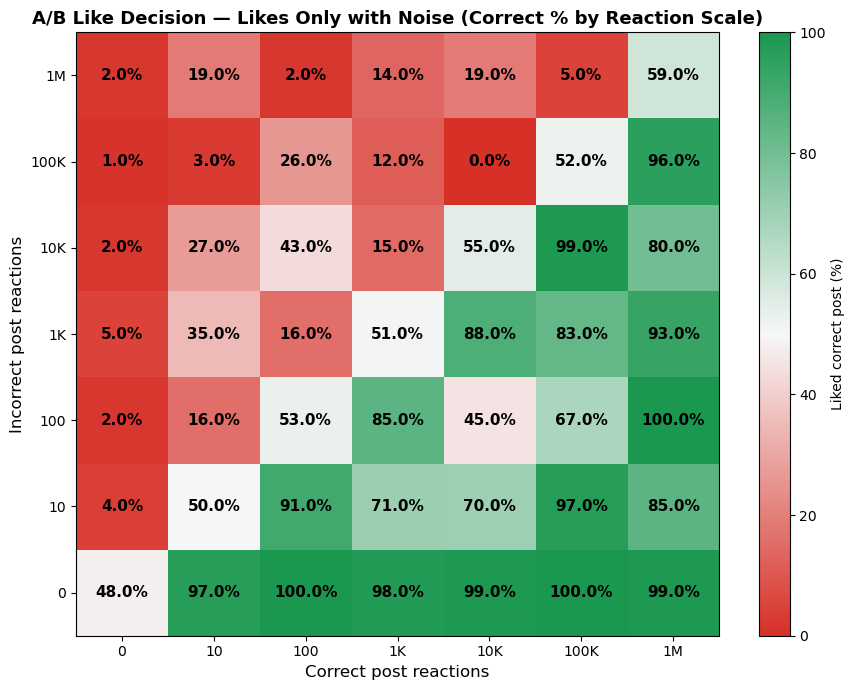

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_results_likes_only_noise_paired_grid.png


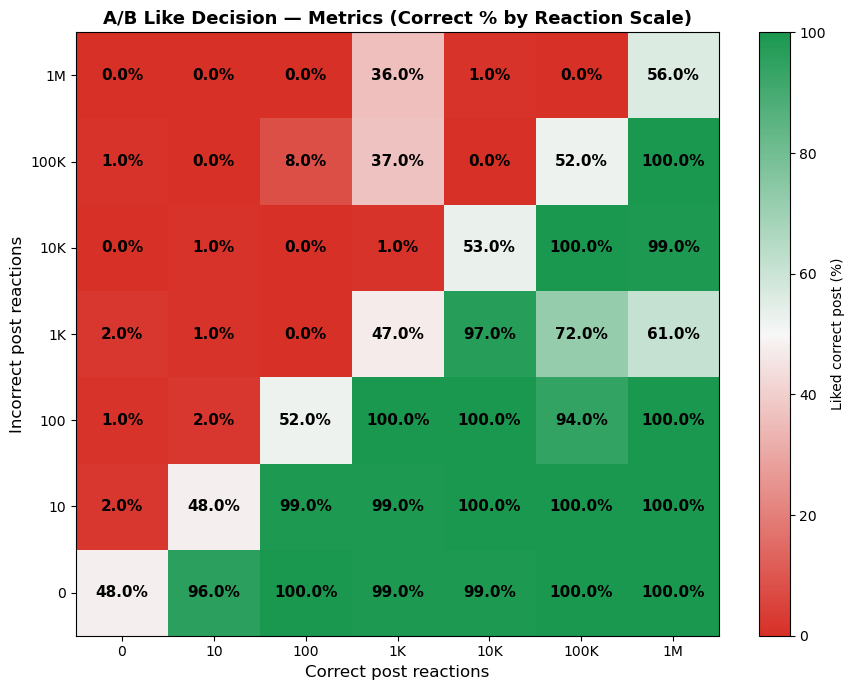

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_results_metrics_paired_grid.png


In [39]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
#plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
#             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



In [ ]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.


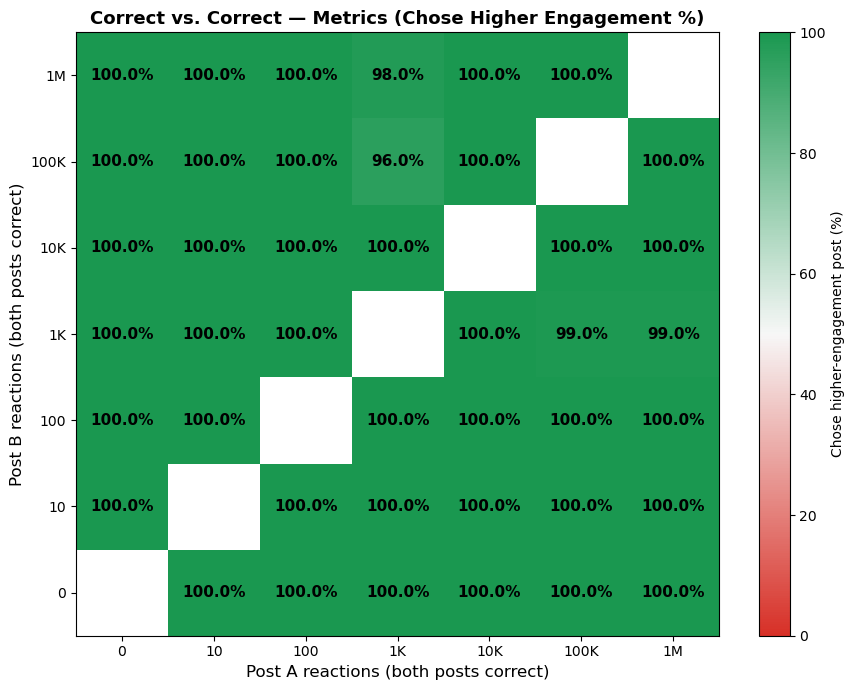

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_results_metrics_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


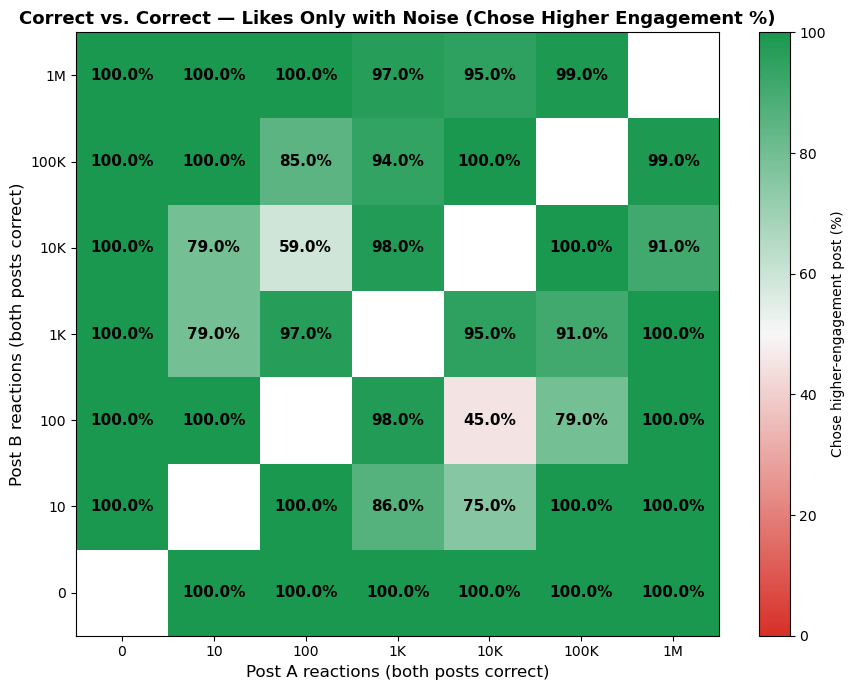

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/qwen3-vl-8b/outputs/e1_results_likes_only_noise_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


In [41]:

import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_cc_grid

# Correct vs. correct control — Metrics (realistic)
plot_cc_grid(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Metrics (Chose Higher Engagement %)")

# Correct vs. correct control — Likes only with noise
plot_cc_grid(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Likes Only with Noise (Chose Higher Engagement %)")


## Two-step prompt pilot (supervisor item, 2026-08)

Tests whether making the model verify factual correctness explicitly *before* the popularity-influenced like/scroll decision improves the diagonal (competence, disparity=0). Two designs run head-to-head, diagonal cells only (7 scales x 100 images = 700 trials each, not the full 49-cell grid -- this is specifically about the diagonal, see `experiments/e1/e1_utils/e1_two_step.py` module docstring for the full rationale and why the grid is narrowed here). Compare each design's `e1_results_metrics_diagonal_twostep_*.json` diagonal accuracy against this notebook's existing single-step `e1_results_metrics_paired.json` diagonal accuracy (Section further up).

Currently pointed at the same `metrics_simple_plot_bigfont` images already used elsewhere in this notebook. If/when the font-size-adjusted ("bigfont") images are composited into full posts, swap `correct_base`/`incorrect_base` below for that directory instead.

In [42]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="paired_verdict", output_filename="e1_results_metrics_diagonal_twostep_paired_verdict.json",
                               inference_fn=run_inference_qwen,
                               baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                               baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")

✅ 001_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 002_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 003_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 004_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 005_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 006_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 007_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 008_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 009_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 010_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 011_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 012_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 013_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (step2 answered B)
✅ 016_correct0_vs_incorrec

In [43]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/correct/PNGs/realistic"
incorrect_base = ROOT_DIR / "spotify_pie_plot/pie_plot_posts/metrics_simple_plot_bigfont/remy-ashford/incorrect/PNGs/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="isolated_verdict", output_filename="e1_results_metrics_diagonal_twostep_isolated_verdict.json",
                               inference_fn=run_inference_qwen,
                               baseline_correct_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/correct/PNGs",
                               baseline_incorrect_dir=ROOT_DIR / "spotify_pie_plot/pie_plot_posts/baselines_simple_plot_bigfont/incorrect/PNGs")
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")

✅ 001_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.)
✅ 002_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 003_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.)
✅ 004_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 005_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 006_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 007_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.)
✅ 008_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 009_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.)
✅ 010_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 011_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 012_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 013_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.)
✅ 014_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 015_correct0_vs_incorrect0 → liked invalid (step2 answered NEITHER.

In [44]:
import json

def diagonal_accuracy(path, filter_diagonal=False):
    records = json.loads((OUTPUT_DIR / path).read_text())
    if filter_diagonal:
        records = [r for r in records if r["correct_scale"] == r["incorrect_scale"]]
    return 100 * sum(r["liked_variant"] == "correct" for r in records) / len(records), len(records)

single_pct, single_n = diagonal_accuracy("e1_results_metrics_paired.json", filter_diagonal=True)
paired_pct, paired_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_paired_verdict.json")
isolated_pct, isolated_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_isolated_verdict.json")

print(f"Single-step (existing, diagonal cells only): {single_pct:.1f}%  (n={single_n})")
print(f"Two-step, paired_verdict:                    {paired_pct:.1f}%  (n={paired_n})")
print(f"Two-step, isolated_verdict:                  {isolated_pct:.1f}%  (n={isolated_n})")

Single-step (existing, diagonal cells only): 50.9%  (n=700)
Two-step, paired_verdict:                    66.6%  (n=700)
Two-step, isolated_verdict:                  74.1%  (n=700)
